# Part 1 - Autencoder
implement and train an autoencoder on a Emoji dataset using PyTorch.

In [14]:
%pip install datasets
%pip install torch

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from textwrap import wrap
from datasets import load_dataset, Dataset, DatasetDict
from torchvision import transforms

mydata = load_dataset('valhalla/emoji-dataset')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

/home/conor/Documents/W2026/demeter_msai437/homeworks/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/conor/Documents/W2026/demeter_msai437/homeworks/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
# include_keywords = ['face','christmas','superhero','supervillian','mage','vampire','monkey','elf','juggling',
#             'boy','girl','adult','person','man','woman','male','female','worker','scientist','technologist',
#             'singer','artist','pilot','astronaut','firefighter','police','sleuth','construction']
include_keywords = ['face']

exclude_keywords = ["clock", "gesture", "moon", "palm", "massage", "wind", "pout",
                    "mouse", "lion", "dragon", "giraffe", "monkey", "dog", "cow", "horse",
                    "zebra", "wolf", "fox", "pig", "rabbit", "panda", "hamster",
                    "bear", "unicorn", "frog"]

def keep_row(example):
    title = (example.get("text") or "").lower()

    inc = any(k.lower() in title for k in include_keywords) if include_keywords else True
    exc = any(k.lower() in title for k in exclude_keywords) if exclude_keywords else False

    return inc and not exc

def preprocess(example):
    im = example["image"].convert("RGB").resize((64, 64), Image.LANCZOS)
    example["image"] = im
    return example

plt.rcParams["figure.figsize"] = [1.5, 1.50]

mydata = load_dataset('valhalla/emoji-dataset')
mydata = mydata.filter(keep_row)
mydata = mydata.map(preprocess)

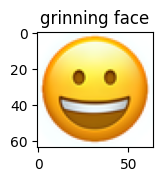

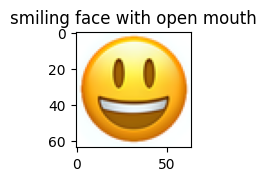

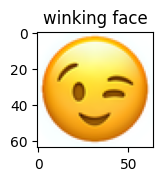

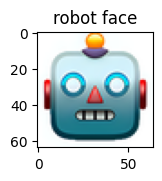

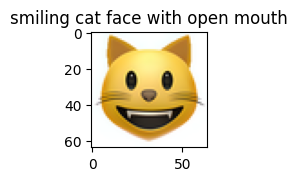

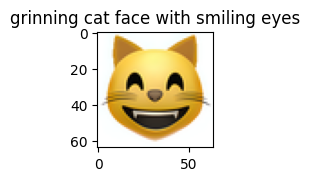

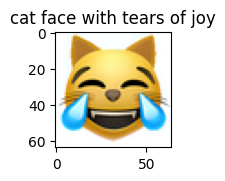

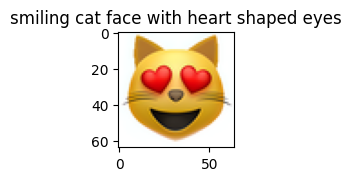

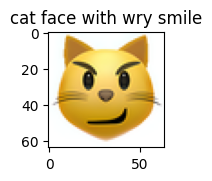

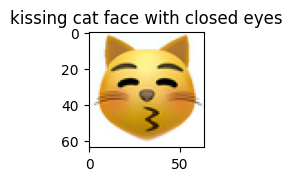

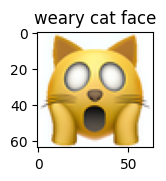

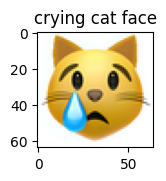

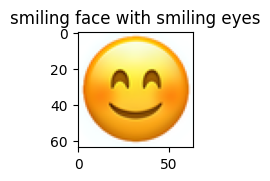

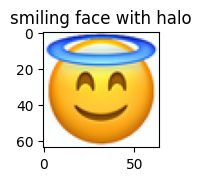

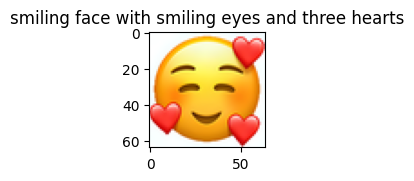

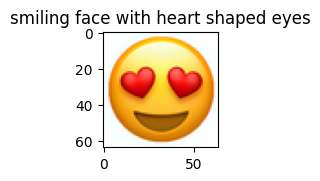

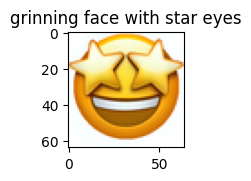

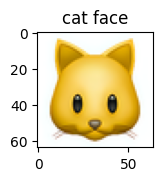

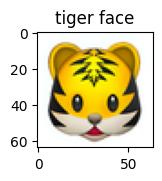

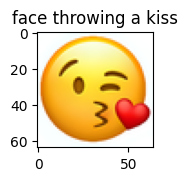

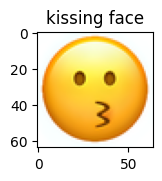

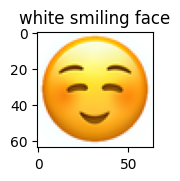

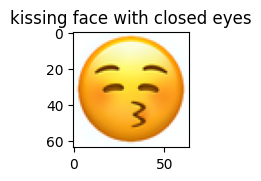

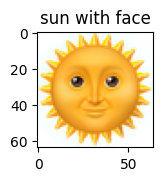

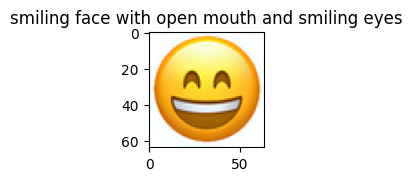

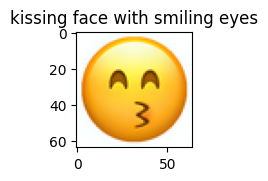

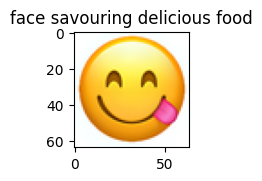

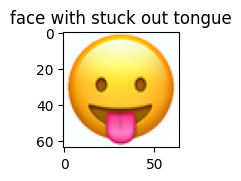

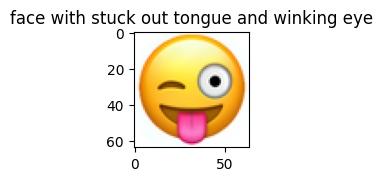

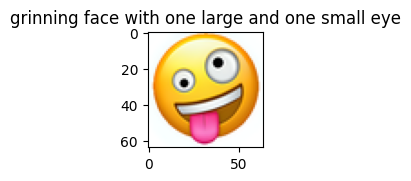

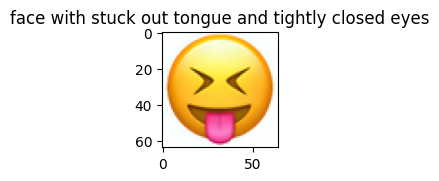

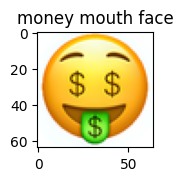

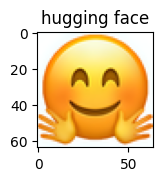

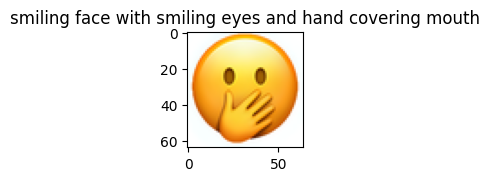

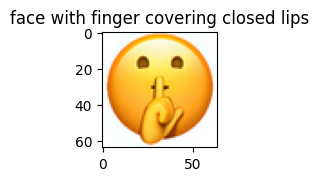

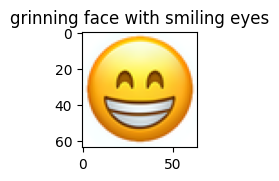

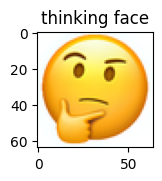

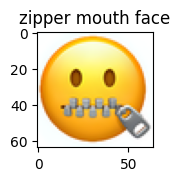

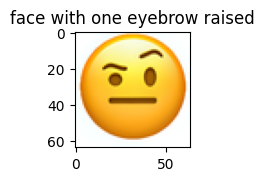

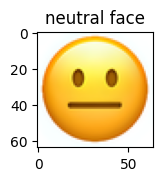

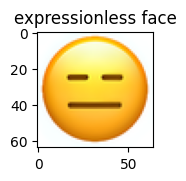

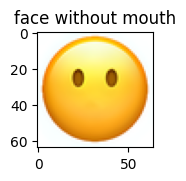

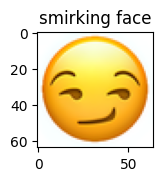

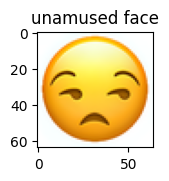

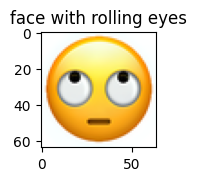

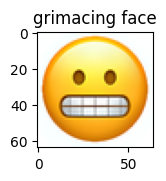

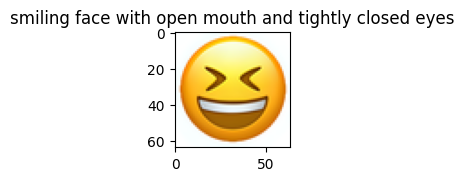

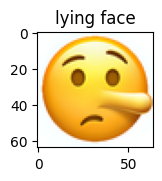

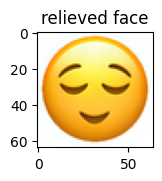

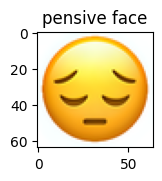

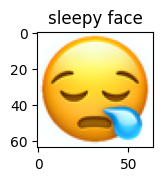

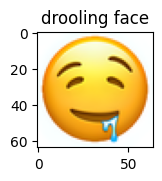

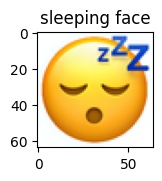

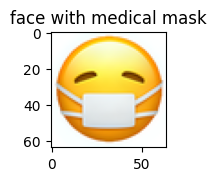

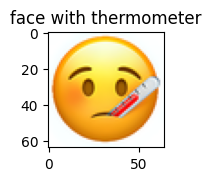

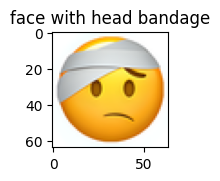

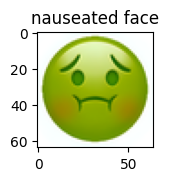

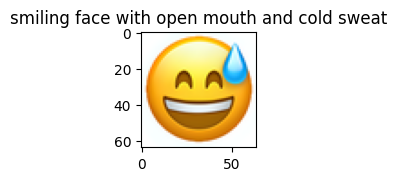

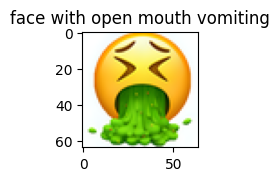

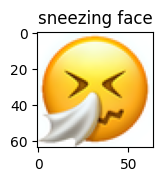

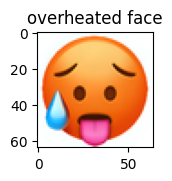

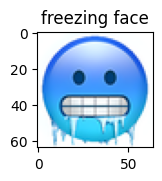

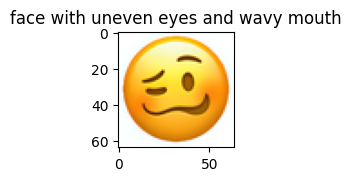

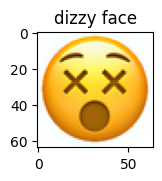

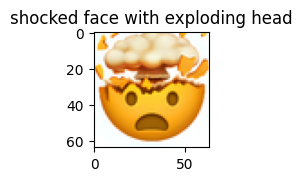

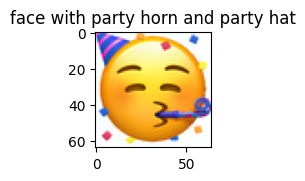

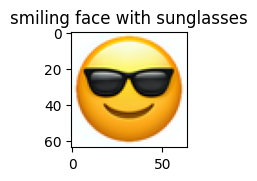

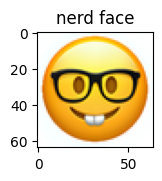

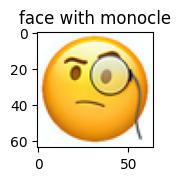

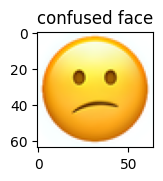

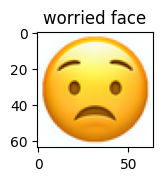

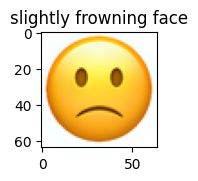

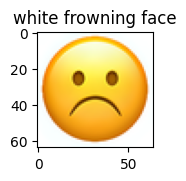

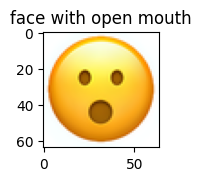

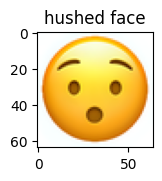

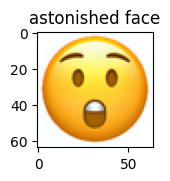

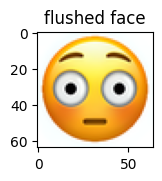

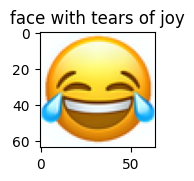

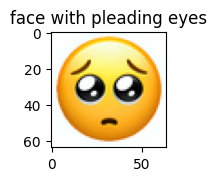

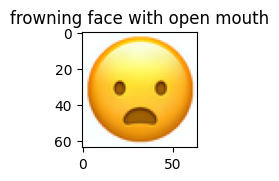

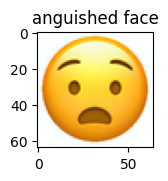

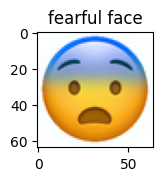

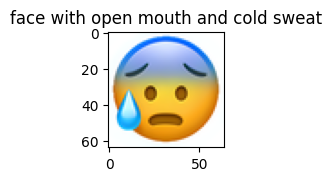

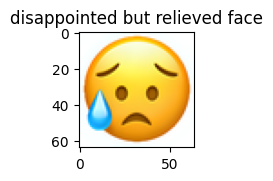

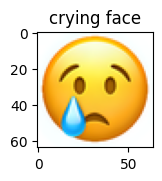

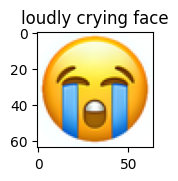

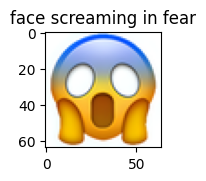

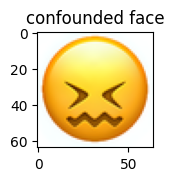

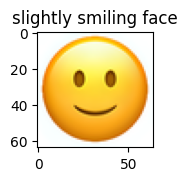

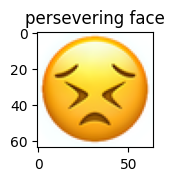

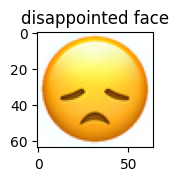

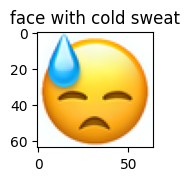

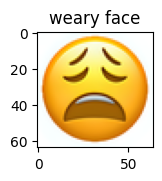

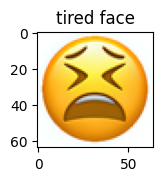

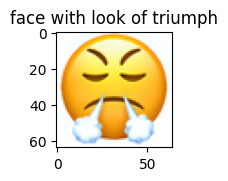

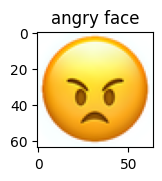

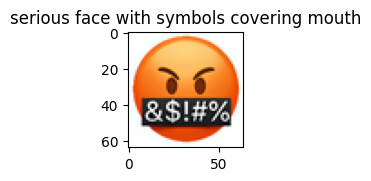

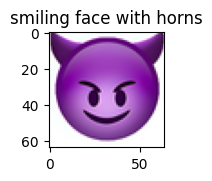

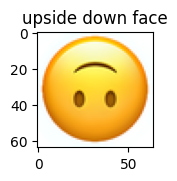

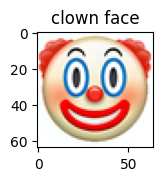

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 100
    })
})


In [16]:
def show_images(dset: Dataset, first_n: int = -1):
  for idx, example in enumerate(dset):
      if first_n > 0 and idx >= first_n:
          break
      plt.imshow(example['image'])
      plt.title(example['text'])
      plt.show()


show_images(mydata['train'])
print(mydata)

# Preprocessing / Data Augmentation

For augmentation, I perform the following operations:
- rotations
- shifts
- zooming
- saturation adjustments
- brightness adjustments

For now, sticking to the assignment guidelines, I will just pre-process my data once, rather than re-augmenting my input data per epoch, though I think that'd be something to try if this doesn't work as well as I'd like.

In [82]:
from PIL import Image, ImageChops, ImageEnhance
import random
from datasets import concatenate_datasets

import numpy as np

def shift_hue(image: Image.Image, hue_shift: float) -> Image.Image:
    """hue_shift in range [-1, 1], wraps around"""
    arr = np.array(image.convert("RGB"), dtype=np.float32) / 255.0
    # convert to HSV
    hsv = np.array(Image.fromarray((arr * 255).astype(np.uint8)).convert("HSV"))
    # shift hue channel (0-255 in PIL's HSV)
    hsv[:, :, 0] = (hsv[:, :, 0].astype(np.int32) + int(hue_shift * 255)) % 256
    # convert back
    return Image.fromarray(hsv, mode="HSV").convert("RGB")

def augment_image(
    image: Image.Image,
    rotate_range=(-90, 90),
    shift_range=(-10, 10),
    zoom_range=(0.8, 1.2),
    hue_range=(-0.2, 0.2),
    saturation_range=(0.5, 1.5),
    brightness_range=(0.5, 1.5),
) -> Image.Image:
    fcolor = (255, 255, 255)

    # Rotate
    angle = random.uniform(*rotate_range)
    image = image.rotate(angle, resample=Image.BILINEAR, expand=False, fillcolor=fcolor)

    # Shift
    dx = random.uniform(*shift_range)
    dy = random.uniform(*shift_range)
    image = image.transform(
        image.size,
        Image.AFFINE,
        (1, 0, -dx, 0, 1, -dy),
        resample=Image.BILINEAR,
        fillcolor=fcolor
    )

    # Zoom (scale)
    zoom_factor = random.uniform(*zoom_range)
    w, h = image.size
    image = image.transform(
        image.size,
        Image.AFFINE,
        (zoom_factor, 0, (1 - zoom_factor) * w / 2, 0, zoom_factor, (1 - zoom_factor) * h / 2),
        resample=Image.BILINEAR,
        fillcolor=fcolor
    )

    # Hue
    hue_shift = random.uniform(*hue_range)
    image = shift_hue(image, hue_shift)

    # Saturation
    sat_factor = random.uniform(*saturation_range)
    image = ImageEnhance.Color(image).enhance(sat_factor)

    # Brightness
    bright_factor = random.uniform(*brightness_range)
    image = ImageEnhance.Brightness(image).enhance(bright_factor)

    return image


def augment_batch(batch):
    batch["image"] = [augment_image(img.convert("RGB")) for img in batch["image"]]
    return batch


def augment_dset(dset, factor=9):
    augmented_datasets = []
    for i in range(factor):
        print(f"Creating augmented copy {i+1}/{factor}...")
        aug_copy = dset.map(augment_batch, batched=True, batch_size=32)
        augmented_datasets.append(aug_copy)
    return concatenate_datasets(augmented_datasets + [dset])


Creating augmented copy 1/9...


Map: 100%|██████████| 100/100 [00:00<00:00, 492.61 examples/s]

Creating augmented copy 2/9...
Creating augmented copy 3/9...
Creating augmented copy 4/9...
Creating augmented copy 5/9...
Creating augmented copy 6/9...
Creating augmented copy 7/9...
Creating augmented copy 8/9...
Creating augmented copy 9/9...
Training set size: 600
Validation set size: 200
Test set size: 200


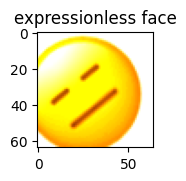

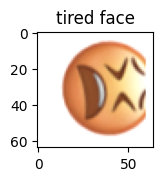

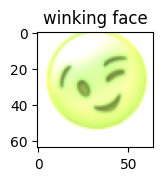

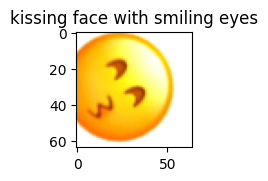

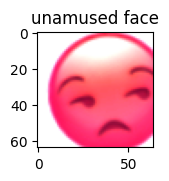

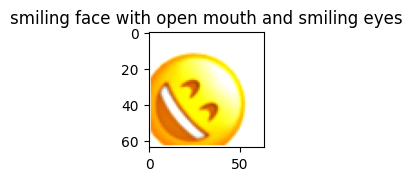

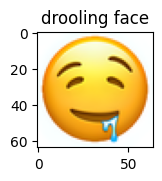

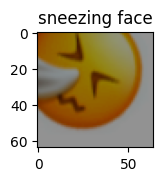

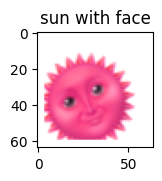

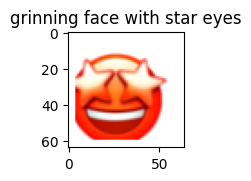

In [ ]:
# Split the dataset BEFORE converting to tensors (while still PIL images)

# we augment ALL, the data then split randomly. this means we get some bit of everything in train, val, and test.
# this is going to sacrifice our ability to evaluate generality, but it will improve our ability to operate on
# the emoji dataset and I care about that more than evaluating on unseen emojis.
augmented = augment_dset(mydata['train'], factor=9)
train_val_test_dataset = augmented.train_test_split(test_size=0.4, seed=RANDOM_SEED)
val_test_dataset = train_val_test_dataset['test'].train_test_split(test_size=0.5, seed=RANDOM_SEED)

train_dataset = train_val_test_dataset['train']
val_dataset = val_test_dataset['train']
test_dataset = val_test_dataset['test']

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# train_dataset = augment_dset(train_dataset, factor=9)
# print(f"\nAugmented training set size: {len(train_dataset)}")
show_images(train_dataset, 10)



In [85]:
# Convert all datasets (train, val, test) from PIL images to tensors

def transform_images(batch):
    # Convert PIL Image to PyTorch Tensor and normalize to [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    batch["image"] = [transform(img.convert("RGB")) for img in batch["image"]]
    return batch

# Convert each dataset to tensors
train_dataset = train_dataset.map(transform_images, batched=True, batch_size=32)
train_dataset.set_format(type="torch", columns=["image"])

val_dataset = val_dataset.map(transform_images, batched=True, batch_size=32)
val_dataset.set_format(type="torch", columns=["image"])

test_dataset = test_dataset.map(transform_images, batched=True, batch_size=32)
test_dataset.set_format(type="torch", columns=["image"])

print(f"Final training set size: {len(train_dataset)}")
print(f"Final validation set size: {len(val_dataset)}")
print(f"Final test set size: {len(test_dataset)}")


Map: 100%|██████████| 200/200 [00:00<00:00, 617.64 examples/s]

Final training set size: 600
Final validation set size: 200
Final test set size: 200


## Model Definition + Training
In this I am roughly inspired [Radford et al](http://arxiv.org/abs/1511.06434)'s DCGAN generator architecture (Figure 1 in the paper linked).



In [86]:
import torch
from torch import nn

class Decoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.z_dim = z_dim
        # simplified 3-layer architecture with max 64 channels
        self.model = nn.Sequential(
            # 1xz -> 64x8x8
            nn.Linear(z_dim, 64 * 8 * 8),
            nn.BatchNorm1d(64 * 8 * 8),
            nn.Unflatten(1, (64, 8, 8)),
            # conv 1: 8x8 -> 16x16
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            # conv 2: 16x16 -> 32x32
            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(),
            # conv 3: 32x32 -> 64x64
            nn.ConvTranspose2d(16, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Encoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.z_dim = z_dim
        # simplified 3-layer architecture with max 64 channels
        self.model = nn.Sequential(
            # conv 1: 64x64 -> 32x32
            nn.Conv2d(3, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # conv 2: 32x32 -> 16x16
            nn.Conv2d(16, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # conv 3: 16x16 -> 8x8
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            # flatten
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, z_dim),
        )

    def forward(self, x):
        return self.model(x)

class EmojiAE(nn.Module):
    """autoencoder for emojis"""
    def __init__(self, z_dim: int):
        """
        z_dim: latent space dimension
        """
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))

def validate_model():
    model = EmojiAE(20)
    dummy = torch.zeros(32, 3, 64, 64)
    print(model(dummy).shape)

def test_shapes():
    model = EmojiAE(20)
    x = torch.zeros(32, 20)
    for layer in model.decoder.model:
        x = layer(x)
        print(layer.__class__.__name__, x.shape)

validate_model()
print()
test_shapes()

torch.Size([32, 3, 64, 64])

Linear torch.Size([32, 4096])
BatchNorm1d torch.Size([32, 4096])
Unflatten torch.Size([32, 64, 8, 8])
ConvTranspose2d torch.Size([32, 32, 16, 16])
BatchNorm2d torch.Size([32, 32, 16, 16])
LeakyReLU torch.Size([32, 32, 16, 16])
ConvTranspose2d torch.Size([32, 16, 32, 32])
BatchNorm2d torch.Size([32, 16, 32, 32])
LeakyReLU torch.Size([32, 16, 32, 32])
ConvTranspose2d torch.Size([32, 3, 64, 64])
Tanh torch.Size([32, 3, 64, 64])


In [75]:
learning_rate = 0.02
batch_size = 50
num_epochs = 60
z_dim = 32

In [76]:
from torch.utils.data import DataLoader

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created for training, validation, and testing.")
print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of validation batches: {len(val_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")

DataLoaders created for training, validation, and testing.
Number of training batches: 12
Number of validation batches: 1
Number of test batches: 1


In [87]:
import torch
from torch import nn

# reset random seeds for reproduceability
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

def pixel_accuracy(y, yhat, close_enough_range=0.07):
    """Outputs [0,1] for percentage of pixels that match between images."""
    return (torch.abs(y - yhat) < close_enough_range).float().mean().item()


# Detect if CUDA is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = EmojiAE(z_dim=z_dim).to(device)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    # Training loop
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    for batch in train_dataloader:
        images = batch["image"].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        train_loss = loss(outputs, images)
        train_loss.backward()
        optimizer.step()
        total_train_loss += train_loss.item()
        total_train_acc += pixel_accuracy(images, outputs)

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    # Evaluation loop
    model.eval()
    total_test_loss = 0
    total_test_acc = 0
    with torch.no_grad():
        for batch in test_dataloader:
            images = batch["image"].to(device)
            outputs = model(images)
            test_loss = loss(outputs, images)
            total_test_loss += test_loss.item()
            total_test_acc += pixel_accuracy(images, outputs)

    avg_test_loss = total_test_loss / len(test_dataloader)
    avg_test_acc = total_test_acc / len(test_dataloader)
    test_losses.append(avg_test_loss)
    test_accuracies.append(avg_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Train Acc: {avg_train_acc:.4f}, Test Acc: {avg_test_acc:.4f}")

    # Save checkpoint at the end of each epoch
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }
    torch.save(checkpoint, 'checkpoint.pth')

print("Training complete.")

Using device: cuda
Epoch [1/60], Train Loss: 0.3774, Test Loss: 0.6096, Train Acc: 0.1183, Test Acc: 0.3064
Epoch [2/60], Train Loss: 0.2063, Test Loss: 0.4032, Train Acc: 0.1925, Test Acc: 0.2995
Epoch [3/60], Train Loss: 0.1621, Test Loss: 0.2201, Train Acc: 0.2232, Test Acc: 0.3198
Epoch [4/60], Train Loss: 0.1362, Test Loss: 0.1768, Train Acc: 0.2588, Test Acc: 0.2957
Epoch [5/60], Train Loss: 0.1259, Test Loss: 0.1645, Train Acc: 0.2731, Test Acc: 0.3085
Epoch [6/60], Train Loss: 0.1150, Test Loss: 0.1374, Train Acc: 0.2712, Test Acc: 0.2888
Epoch [7/60], Train Loss: 0.1081, Test Loss: 0.1247, Train Acc: 0.2808, Test Acc: 0.2793
Epoch [8/60], Train Loss: 0.0980, Test Loss: 0.1273, Train Acc: 0.2958, Test Acc: 0.2594
Epoch [9/60], Train Loss: 0.0906, Test Loss: 0.1237, Train Acc: 0.3014, Test Acc: 0.3525
Epoch [10/60], Train Loss: 0.0827, Test Loss: 0.1131, Train Acc: 0.3303, Test Acc: 0.3270
Epoch [11/60], Train Loss: 0.0758, Test Loss: 0.1107, Train Acc: 0.3554, Test Acc: 0.3753


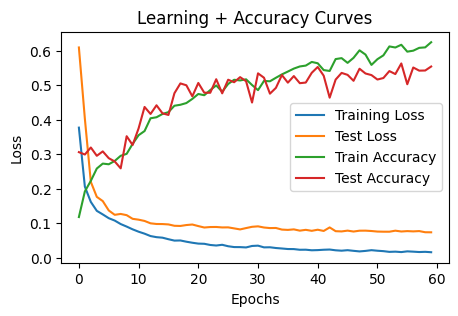

In [88]:
plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.title('Learning + Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Upload checkpoint to huggingface.

In [94]:
from huggingface_hub import HfApi, login

try:
    from google.colab import userdata
    token = userdata.get('HUGGINGFACE_HUB_TOKEN')
    login(token=token)
    print("Logged in to Hugging Face Hub successfully!")
except ImportError:
    from dotenv import load_dotenv
    import os

    print("Not running in Colab, attempting to load Hugging Face token from .env file...")
    load_dotenv()

    token = os.getenv('HUGGINGFACE_HUB_TOKEN')
    login(token=token)
    print("Logged in to Hugging Face Hub successfully!")
    
repo_id = "cwoodhayes/EmojiAE"
api = HfApi()

# Create the repository if it doesn't exist
# This assumes you are logged in correctly and have permissions
try:
    api.create_repo(repo_id=repo_id, private=False, exist_ok=True)
    print(f"Repository '{repo_id}' ensured to exist.")
except Exception as e:
    print(f"Could not create or access repository '{repo_id}'. Error: {e}")

# Upload the checkpoint file
checkpoint_path = "checkpoint.pth"
if os.path.exists(checkpoint_path):
    try:
        api.upload_file(
            path_or_fileobj=checkpoint_path,
            path_in_repo="checkpoint.pth",
            repo_id=repo_id,
            repo_type="model",
        )
        print(f"Checkpoint 'checkpoint.pth' successfully uploaded to https://huggingface.co/{repo_id}")
    except Exception as e:
        print(f"Failed to upload checkpoint: {e}")
else:
    print(f"Checkpoint file '{checkpoint_path}' not found. Please ensure it was created during training.")

Not running in Colab, attempting to load Hugging Face token from .env file...
Logged in to Hugging Face Hub successfully!
Repository 'cwoodhayes/EmojiAE' ensured to exist.


Processing Files (1 / 1): 100%|██████████| 4.37MB / 4.37MB, 4.37MB/s  
New Data Upload: 100%|██████████| 4.37MB / 4.37MB, 4.37MB/s  


Checkpoint 'checkpoint.pth' successfully uploaded to https://huggingface.co/cwoodhayes/EmojiAE


## Evaluation

Just visually assessing the trained model on a few examples in the validation set.

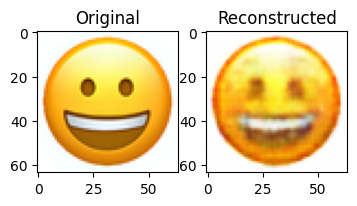

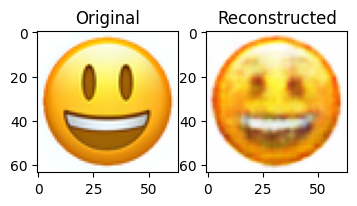

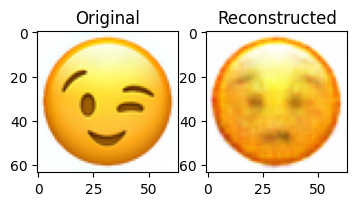

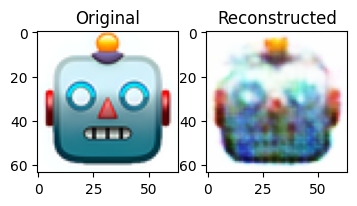

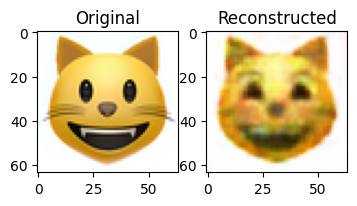

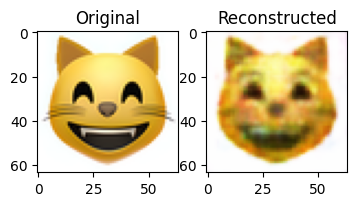

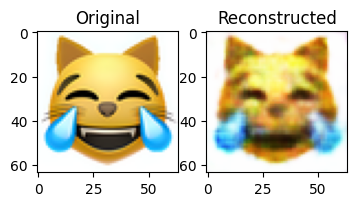

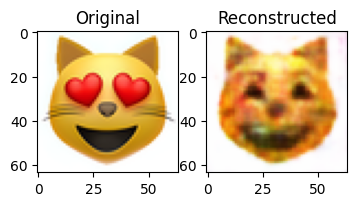

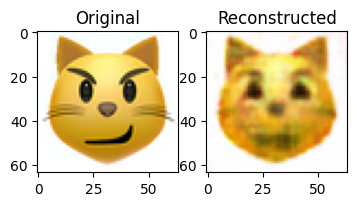

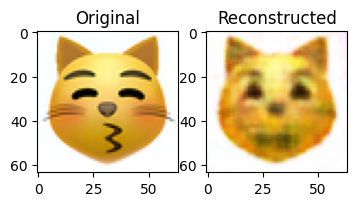

In [92]:
from torchvision.transforms.functional import to_pil_image

def show_model_result(model: EmojiAE, dset: Dataset, first_n: int = -1):
    model.eval()
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    with torch.no_grad():
        for idx, example in enumerate(dset):
            if first_n > 0 and idx >= first_n:
                break

            fig = plt.figure(figsize=(4, 2))
            fig.add_subplot(1, 2, 1)

            image = example['image']
            if isinstance(image, torch.Tensor):
                original = image.to(device)
                img_orig = to_pil_image((original.squeeze(0) + 1) / 2)
            else:
                original = transform(image.convert("RGB")).to(device)
                img_orig = image

            plt.imshow(img_orig)
            plt.title('Original')

            fig.add_subplot(1, 2, 2)
            reconstructed = model(original.unsqueeze(0))
            img = to_pil_image((reconstructed.squeeze(0).cpu() + 1) / 2)
            plt.imshow(img)
            plt.title('Reconstructed')

            plt.show()

# showing results from un-augmented data.
show_model_result(model, mydata['train'], 10)
# show_model_result(model, test_dataset, 5)

## Commentary

### a. describe your dataset and the steps that you used to create it
My dataset consists of emojis from the "valhalla/emoji-dataset" on Hugging Face. I filtered the dataset to include only emojis related to "face" and exclude certain categories like animals, gestures, and objects. After filtering, I resized the images to 64x64 pixels. To augment the dataset, I applied random transformations such as rotation, shifting, zooming, hue adjustment, saturation changes, and brightness changes. This augmentation was done to increase the diversity of the training data and help the model generalize better. Finally, I split the augmented dataset into training, validation, and test sets.
### b. provide a summary of your architecture
### c. discuss and explain your design choices,
### d. list hyper-parameters used in the model,
### e. plot learning curves for training and validation loss as a function of training epochs,
### f. provide the final average error of your autoencoder on your test set,
### g. provide a side-by-side example of 5 input and output images.
### h. discuss any decisions or observations that you find relevant.

# Part 2 - Latent Space Arithmetic
Select an attribute from the Emoji dataset (internal or external to your selected
subset) to compose with any image from your selected subset.

I will attempt to make a nerdy cat emoji:
(nerd emoji - smiling emoji) + cat emoji.

Found: nerd face
Found: white smiling face
Found: smiling cat face with open mouth
Nerd face latent shape: torch.Size([1, 32])
Smiling face latent shape: torch.Size([1, 32])
Cat face latent shape: torch.Size([1, 32])


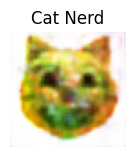

In [93]:
# grab my emojis:

# grab my emojis:
# Find the nerd face emoji from the original dataset
def find_emoji_by_name(dataset, keyword):
    for example in dataset['train']:
        if keyword.lower() in example['text'].lower():
            return example
    return None

nerd_face = find_emoji_by_name(mydata, "nerd face")
smiling_face = find_emoji_by_name(mydata, "white smiling face")
cat_face = find_emoji_by_name(mydata, "smiling cat face with open mouth")

if nerd_face:
    print(f"Found: {nerd_face['text']}")
if smiling_face:
    print(f"Found: {smiling_face['text']}")
if cat_face:
    print(f"Found: {cat_face['text']}")

# first, get the latent space representations using the encoder
model.eval()
with torch.no_grad():
    enc = model.encoder
    # Preprocess the images to tensors
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    nerd_tensor = transform(nerd_face['image'].convert("RGB")).unsqueeze(0).to(device)
    smiling_tensor = transform(smiling_face['image'].convert("RGB")).unsqueeze(0).to(device)
    cat_tensor = transform(cat_face['image'].convert("RGB")).unsqueeze(0).to(device)

    # Get latent representations
    z_nerd = enc(nerd_tensor)
    z_smiling = enc(smiling_tensor)
    z_cat = enc(cat_tensor)

    print(f"Nerd face latent shape: {z_nerd.shape}")
    print(f"Smiling face latent shape: {z_smiling.shape}")
    print(f"Cat face latent shape: {z_cat.shape}")

    # now do the vector arithmetic
    z_cat_nerd = (z_nerd - z_smiling) + z_cat

    # and decode it
    cat_nerd = model.decoder(z_cat_nerd)

    cat_nerd_img = to_pil_image((cat_nerd.squeeze(0).cpu() + 1) / 2)
    plt.imshow(cat_nerd_img)
    plt.title("Cat Nerd")
    plt.axis("off")
    plt.show()

## Qualitative Evaluation
On the plus side, the cat outline is pretty accurate, and a vague blurry set of glasses is visible.
On the downside, the result is quite blurry, with strange green color artifacts that aren't present in any of the source images.

This green artifact situation is likely due to the interpolation-y operation that's occurring when we decode the cat nerd latent vector $z_c$. $z_c$ isn't present in the training data, so we can think of the decoding of that vector as finding some kind of interpolation between regions of the output image space where we actually have training example outputs. In the case of the particular function we've learned here, I suppose that empty region where the cat nerd is also has some green-ness (which would come from the green input data produced by my hue augmentation).

It's possible that some additional regularization would help resolve this. I think that green region intruding into the cat nerd space implies a more complex decision boundary that allows the green to slip over where it doesn't belong, so encouraging a simpler boundary might help.

The blurriness is another issue. It occurs in the full autoencoder as well. Blurriness makes a vague sort of sense, since we're upscaling from a low-d feature space and don't have the information necessary to fill in a high-d image perfectly, but I'm not certain that blurriness is a necessary manifestation of that; why couldn't we have higher-def shapes & edges that just don't quite correspond to the correct ones in the input data?

I suppose a way to improve on that would be to somehow encourage firm lines. I could construct a regularizer that does this, perhaps by going over the output images with something like canny edge detection and summing over dark pixels to reward sharper image gradients.

It'd be fun to try these out, but I've run out of time I have to spend on this, so the real results of these trials will have to remain a mystery for now.